In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from tensorflow import keras
from typing import List
from sklearn.neighbors import KNeighborsClassifier as KNC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.inspection import permutation_importance

# Downloading dataset

In [2]:
# CONSTANTS
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
SCORING = 'recall'

In [3]:
results_a = {}
results_r = {}
results_p = {}

In [4]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(URL, names=columns)
df['target'] = (df['target'] > 0).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Feature engineering

In [5]:
missing_values = len(df[(df == '?').any(axis=1)])
print(f'Missing values (?): {missing_values} [{missing_values/len(df):.2%}%]')
for c in columns:
  missing = len(df[df[c]=='?'])
  if missing:
    print(f'\t{c}: {missing} [{missing/len(df):.2%}%]')

df.replace('?', np.nan, inplace=True)
print("Nans after replaceing '?'")
display(df.isna().sum())
df = df.astype(float)
df = df.dropna()  # ~2% missing

Missing values (?): 6 [1.98%%]
	ca: 4 [1.32%%]
	thal: 2 [0.66%%]
Nans after replaceing '?'


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


,count
target,
0.0,160
1.0,137


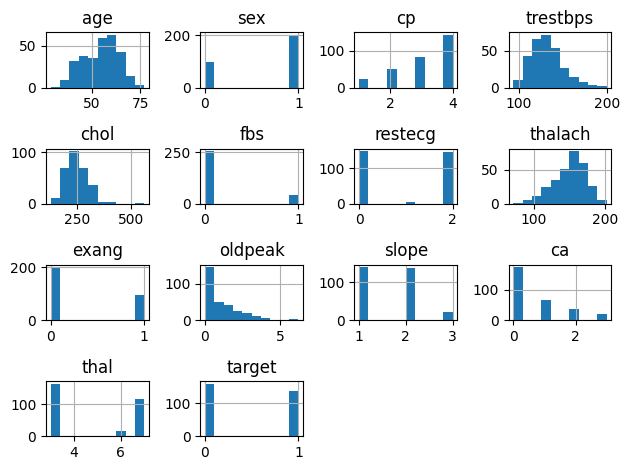

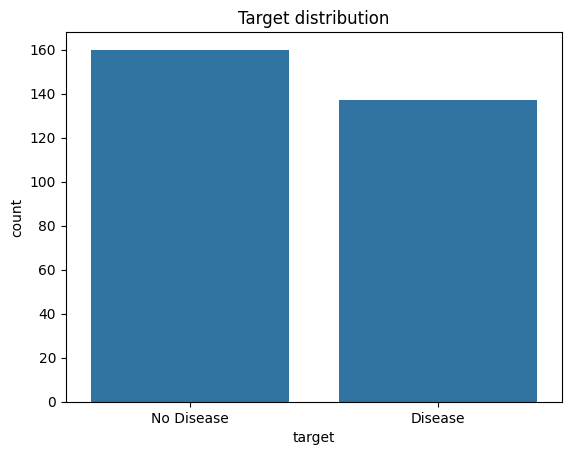

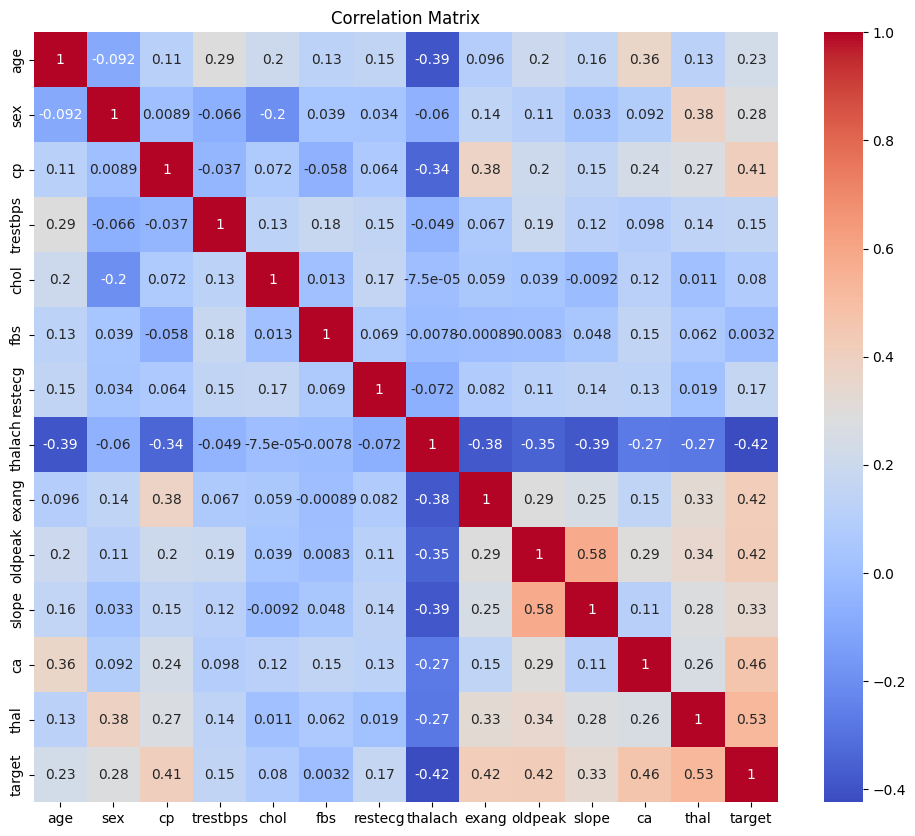

In [6]:
display(df.describe())

display(df['target'].value_counts())

df.hist()
plt.tight_layout()
plt.show()

sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Target distribution')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

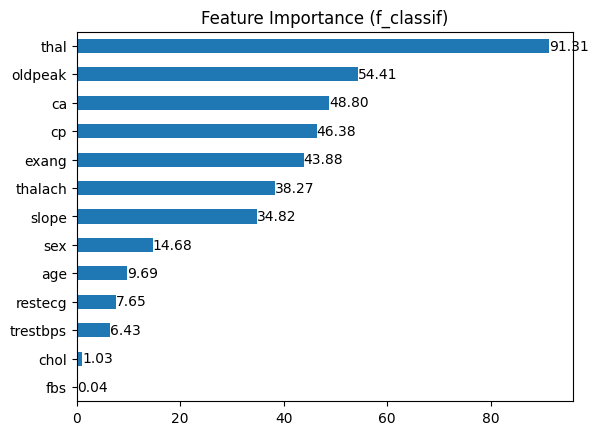

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X.columns)
ax = scores.sort_values().plot(kind='barh')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.title('Feature Importance (f_classif)')
plt.show()
# Max correlation = 0.58, no need for changes

In [8]:
def model_summary(y_test, y_pred, title):
  cm = confusion_matrix(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)

  print(f"Accuracy:  {acc:.4f}")
  print(f"Recall:    {rec:.4f}")
  print(f"Precision: {prec:.4f}")

  print('\n',classification_report(y_test, y_pred))
  sns.heatmap(cm, annot=True)
  plt.title(f'Confusion Matrix - {title}')
  plt.show()
  return acc, rec, prec

# Original dataset

## MLP

### Scikit-learn

Accuracy:  0.8667
Recall:    0.8571
Precision: 0.8571

               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        32
         1.0       0.86      0.86      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



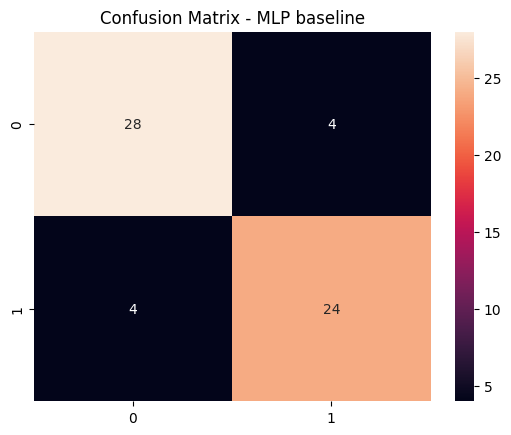

In [9]:
mlp_baseline = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline.fit(X_train, y_train)

y_pred_MLP_baseline = mlp_baseline.predict(X_test)
results_a['MLP baseline'], results_r['MLP baseline'], results_p['MLP baseline'] = model_summary(y_test, y_pred_MLP_baseline, "MLP baseline")

Najlepsze parametry: {'activation': 'logistic', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}
Recall (walidacja): 0.7965
Recall (test): 0.8214
Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



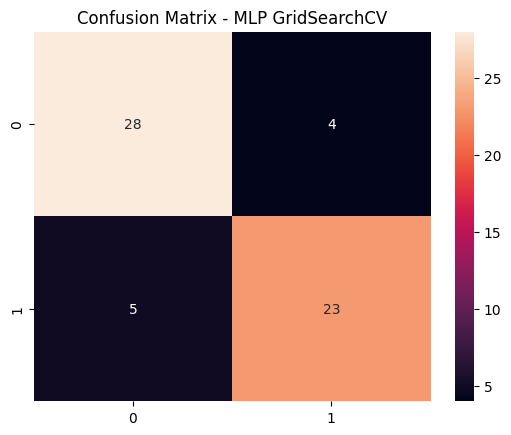

In [10]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (50, 50), (100, 50), (100, 100)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.00001, 0.0001, 0.001],
}

mlp_grid = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid = GridSearchCV(mlp_grid, param_grid_mlp, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {mlp_grid.best_params_}')
print(f'Recall (walidacja): {mlp_grid.best_score_:.4f}')
print(f'Recall (test): {mlp_grid.score(X_test, y_test):.4f}')

y_pred_MLP = mlp_grid.predict(X_test)
results_a['MLP GridSearchCV'], results_r['MLP GridSearchCV'], results_p['MLP GridSearchCV'] = model_summary(y_test, y_pred_MLP, "MLP GridSearchCV")

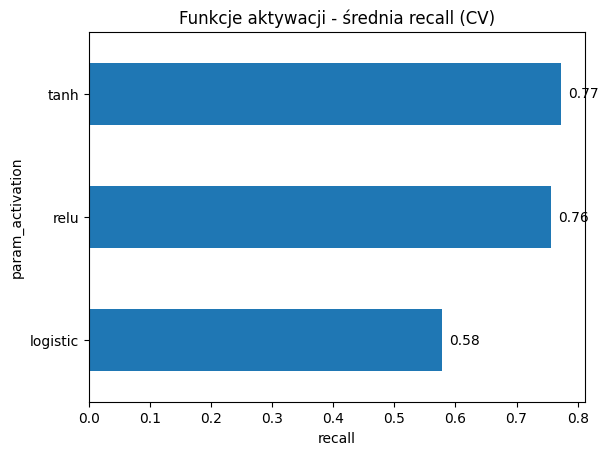

In [11]:
cv_results = pd.DataFrame(mlp_grid.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
ax = activation_results.sort_values().plot(kind='barh', title=f'Funkcje aktywacji - średnia {SCORING} (CV)')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5)
plt.xlabel(SCORING)
plt.show()

### Tensorflow

In [12]:
tf.config.experimental.enable_op_determinism()
tf.keras.utils.set_random_seed(RANDOM_STATE)
def train_model(hidden_layers:List[int], activation, optymizer, dropout, epochs):
  model = keras.Sequential()
  for i in hidden_layers:
    model.add(keras.layers.Dense(i, activation=activation))
    model.add(keras.layers.Dropout(dropout))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer=optymizer, loss='binary_crossentropy', metrics=[SCORING])
  early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
  model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stop])
  return model

Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[50] 0.8571
[100] 0.8214
[200] 0.7857
[50, 50] 0.7500
[100, 50] 0.8214
[100, 100] 0.8571
[200, 100] 0.7857
[100, 50, 25] 0.7857
[25, 50, 100] 0.7500
[100, 50, 100] 0.8214
Best: {'layers': [50], 'rec': 0.8571428656578064} 

Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



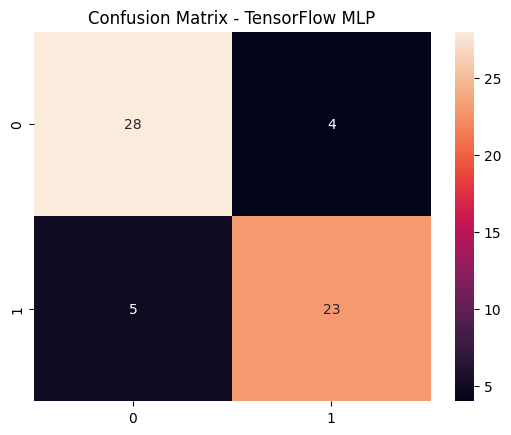

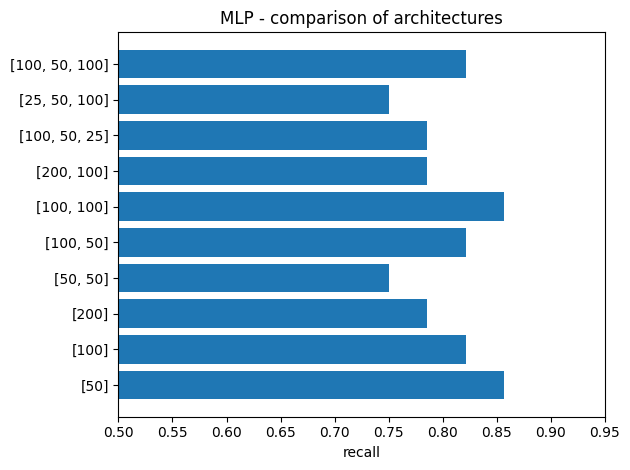

In [13]:
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
architectures = [
    [50],
    [100],
    [200],
    [50,50],
    [100,50],
    [100,100],
    [200,100],
    [100,50,25],
    [25,50,100],
    [100,50,100]
]
arch_accs = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test, y_test, verbose=0, return_dict=True)[SCORING]
  arch_accs.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

model = train_model(best['layers'], 'relu', 'adam', 0.2, 200)
y_pred_TF_proba = model.predict(X_test, verbose=0)
y_pred_TF = (y_pred_TF_proba > 0.4).astype(int)
results_a['MLP TensorFlow'], results_r['MLP TensorFlow'], results_p['MLP TensorFlow'] = model_summary(y_test, y_pred_TF, "MLP TensorFlow")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_accs)
plt.xlabel(SCORING)
plt.title('MLP - comparison of architectures')
plt.xlim(0.5, 0.95)
plt.tight_layout()
plt.show()

## SVC

### Baseline

Accuracy:  0.8500
Recall:    0.7857
Precision: 0.8800

               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        32
         1.0       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



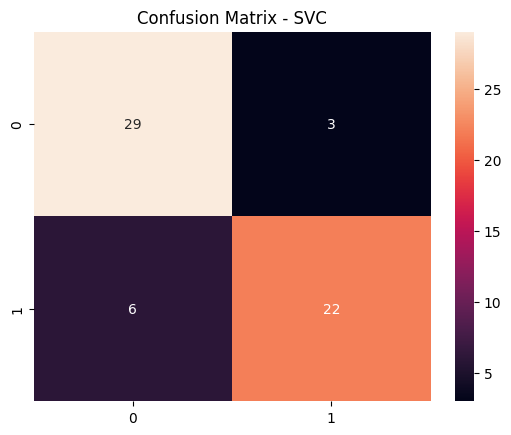

In [14]:
svc_baseline = SVC(random_state=RANDOM_STATE)
svc_baseline.fit(X_train, y_train)

y_pred_SVC_baseline = svc_baseline.predict(X_test)
results_a['SVC baseline'], results_r['SVC baseline'], results_p['SVC baseline'] = model_summary(y_test, y_pred_SVC_baseline, "SVC")

### GridSearchCV

Najlepsze parametry: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Recall (walidacja): 0.8152
Recall (test): 0.7857
Accuracy:  0.8167
Recall:    0.7857
Precision: 0.8148

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        32
         1.0       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



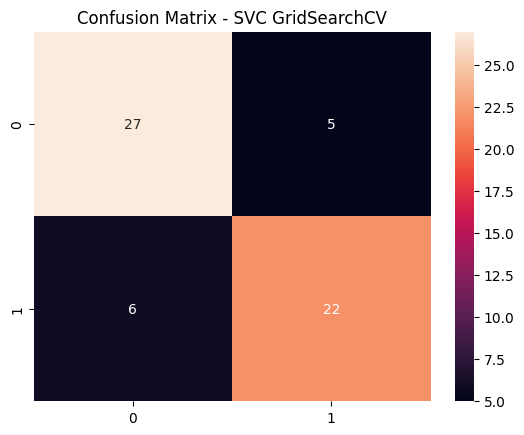

In [15]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

svc_grid = SVC(random_state=RANDOM_STATE)
svc_grid = GridSearchCV(svc_grid, param_grid_svc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
svc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {svc_grid.best_params_}')
print(f'Recall (walidacja): {svc_grid.best_score_:.4f}')
print(f'Recall (test): {svc_grid.score(X_test, y_test):.4f}')

y_pred_SVC = svc_grid.predict(X_test)
results_a['SVC GridSearchCV'], results_r['SVC GridSearchCV'], results_p['SVC GridSearchCV'] = model_summary(y_test, y_pred_SVC, "SVC GridSearchCV")

### Kernel comparison

In [16]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train, y_train)
    y_pred_k = svc.predict(X_test)
    print(f'{kernel:10s} {recall_score(y_test, y_pred_k):.4f}')

linear     0.7857
rbf        0.7857
poly       0.7857
sigmoid    0.7857


## KNeighborsClassifier

### Baseline

Accuracy:  0.8833
Recall:    0.8214
Precision: 0.9200

               precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        32
         1.0       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



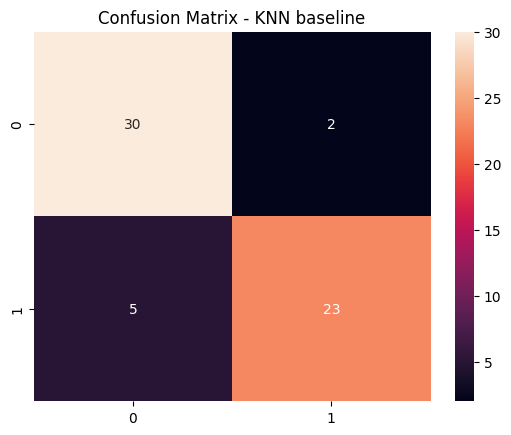

In [17]:
knn_base=KNC()
knn_base.fit(X_train,y_train)

y_pred_knn_base = knn_base.predict(X_test)
results_a['KNN baseline'], results_r['KNN baseline'], results_p['KNN baseline'] = model_summary(y_test, y_pred_knn_base, "KNN baseline")

### GridSearchCV

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Recall (walidacja): 0.7874
Recall (test): 0.7857
Accuracy:  0.8667
Recall:    0.7857
Precision: 0.9167

               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        32
         1.0       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



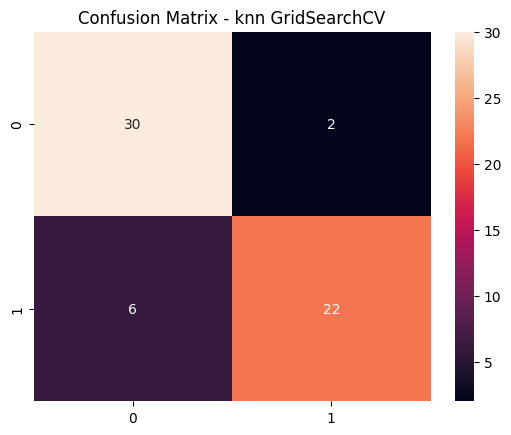

In [18]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = KNC()
knn_grid = GridSearchCV(knn_grid, param_grid_knn, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {knn_grid.best_params_}')
print(f'Recall (walidacja): {knn_grid.best_score_:.4f}')
print(f'Recall (test): {knn_grid.score(X_test, y_test):.4f}')

y_pred_knn = knn_grid.predict(X_test)
results_a['KNN GridSearchCV'], results_r['KNN GridSearchCV'], results_p['KNN GridSearchCV'] = model_summary(y_test, y_pred_knn, "KNN GridSearchCV")

## RandomForestClassifier

### Baseline

Accuracy:  0.8667
Recall:    0.8214
Precision: 0.8846

               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88        32
         1.0       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



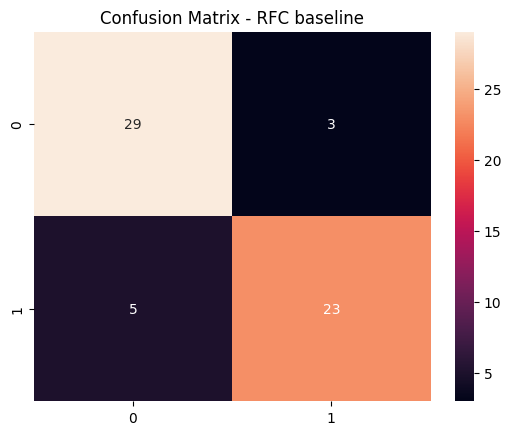

In [19]:
rfc_base = RFC(random_state=RANDOM_STATE)
rfc_base.fit(X_train, y_train)

y_pred_rfc_base = rfc_base.predict(X_test)
results_a['RFC baseline'], results_r['RFC baseline'], results_p['RFC baseline'] = model_summary(y_test, y_pred_rfc_base, "RFC baseline")

### GridSearchCV

Najlepsze parametry: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Recall (walidacja): 0.8061
Recall (test): 0.7500
Accuracy:  0.8333
Recall:    0.7500
Precision: 0.8750

               precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



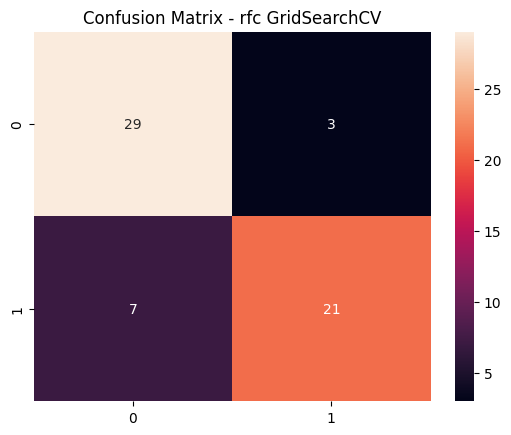

In [20]:
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = RFC(random_state=RANDOM_STATE)
rfc_grid = GridSearchCV(rfc_grid, param_grid_rfc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {rfc_grid.best_params_}')
print(f'Recall (walidacja): {rfc_grid.best_score_:.4f}')
print(f'Recall (test): {rfc_grid.score(X_test, y_test):.4f}')

y_pred_rfc = rfc_grid.predict(X_test)
results_a['rfc GridSearchCV'], results_r['rfc GridSearchCV'], results_p['rfc GridSearchCV'] = model_summary(y_test, y_pred_rfc, "rfc GridSearchCV")

### Feature importance

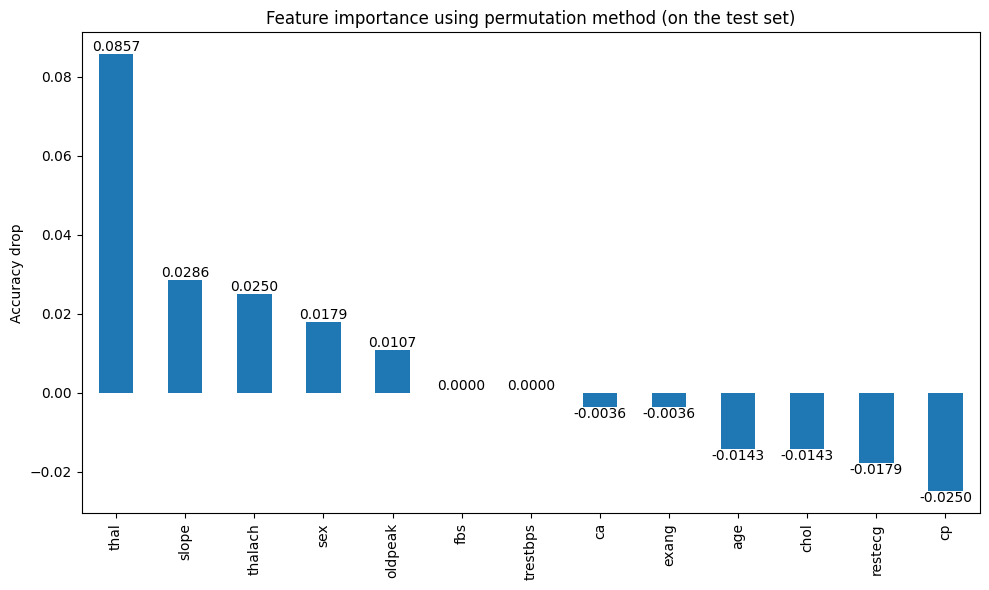

In [21]:
result = permutation_importance(
    rfc_grid, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(result.importances_mean, index=columns[0:13]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = perm_importances.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.4f')
plt.title("Feature importance using permutation method (on the test set)")
plt.ylabel("Accuracy drop")
plt.tight_layout()
plt.show()

## Base model comparison

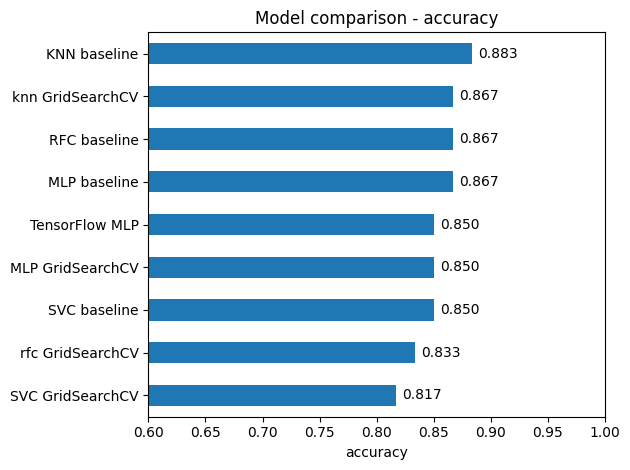

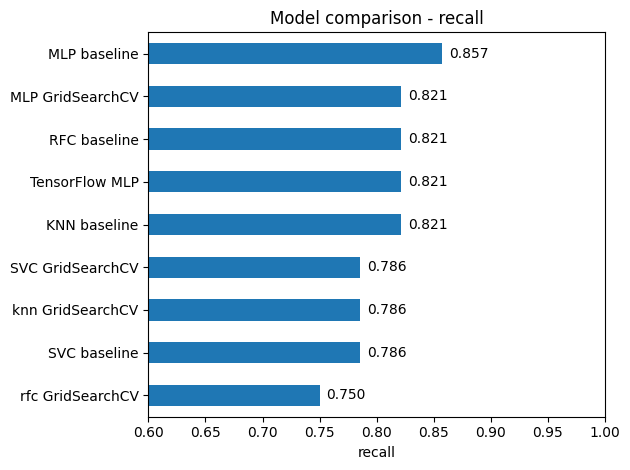

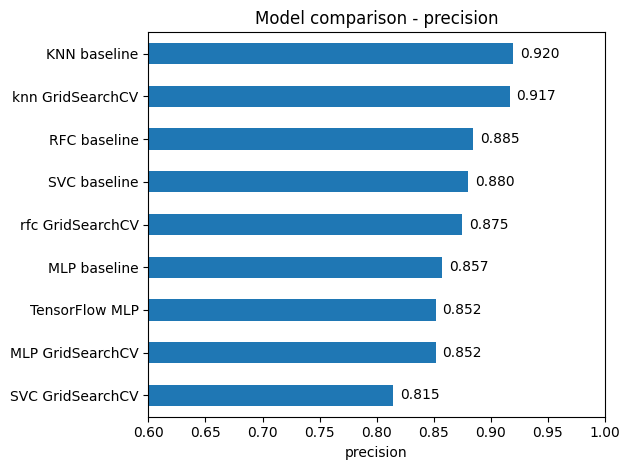

In [22]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  ax = pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()

# Reduced dataset

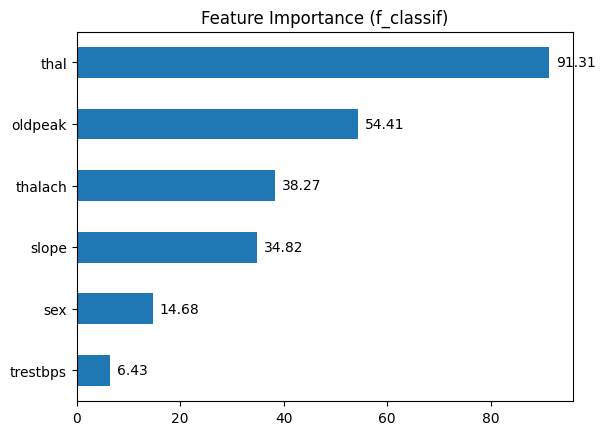

In [23]:
X = df.drop(['target', 'cp', 'restecg', 'chol', 'age', 'exang', 'ca', 'fbs'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X.columns)
ax = scores.sort_values().plot(kind='barh')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5)
plt.title('Feature Importance (f_classif)')
plt.show()

## MLP

### Scikit-learn

Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



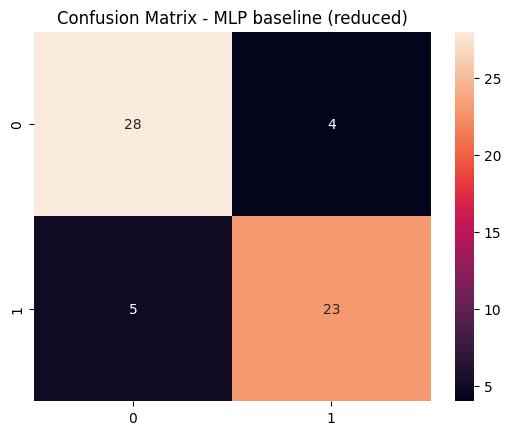

In [24]:
mlp_baseline = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline.fit(X_train, y_train)

y_pred_MLP_baseline = mlp_baseline.predict(X_test)
results_a['MLP baseline (reduced)'], results_r['MLP baseline (reduced)'], results_p['MLP baseline (reduced)'] = model_summary(y_test, y_pred_MLP_baseline, "MLP baseline (reduced)")

Najlepsze parametry: {'activation': 'tanh', 'alpha': 1e-05, 'hidden_layer_sizes': (50,), 'solver': 'adam'}
Recall (walidacja): 0.7606
Recall (test): 0.7500
Accuracy:  0.8000
Recall:    0.7500
Precision: 0.8077

               precision    recall  f1-score   support

         0.0       0.79      0.84      0.82        32
         1.0       0.81      0.75      0.78        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



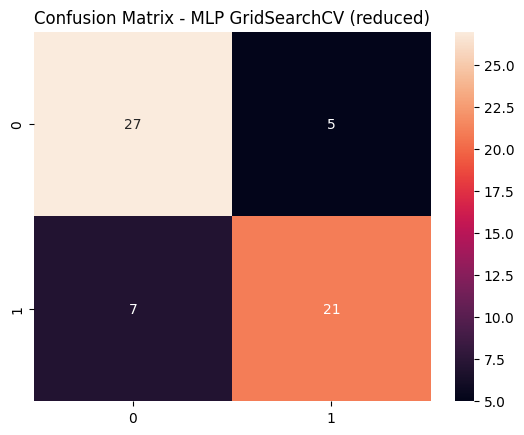

In [25]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (50, 50), (100, 50), (100, 100)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.00001, 0.0001, 0.001],
}

mlp_grid = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid = GridSearchCV(mlp_grid, param_grid_mlp, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {mlp_grid.best_params_}')
print(f'Recall (walidacja): {mlp_grid.best_score_:.4f}')
print(f'Recall (test): {mlp_grid.score(X_test, y_test):.4f}')

y_pred_MLP = mlp_grid.predict(X_test)
results_a['MLP GridSearchCV (reduced)'], results_r['MLP GridSearchCV (reduced)'], results_p['MLP GridSearchCV (reduced)'] = model_summary(y_test, y_pred_MLP, "MLP GridSearchCV (reduced)")

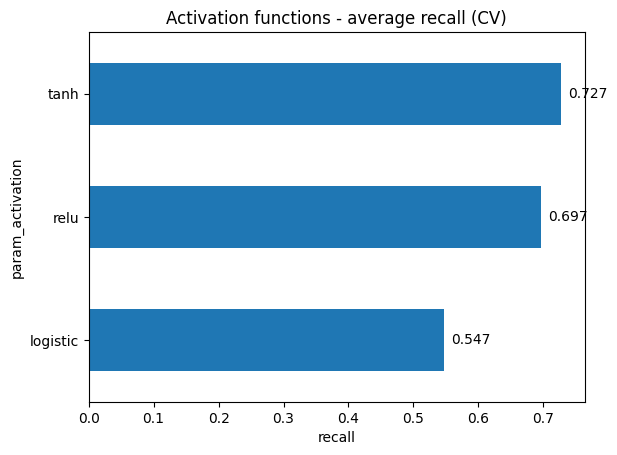

param_activation
tanh        0.727237
relu        0.696958
logistic    0.546753
Name: mean_test_score, dtype: float64


In [26]:
cv_results = pd.DataFrame(mlp_grid.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
ax = activation_results.sort_values().plot(kind='barh', title=f'Activation functions - average {SCORING} (CV)')
ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)
plt.xlabel(SCORING)
plt.show()
print(activation_results.sort_values(ascending=False))

### Tensorflow

Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[50] 0.7143
[100] 0.7143
[200] 0.7143
[50, 50] 0.7143
[100, 50] 0.6786
[100, 100] 0.6786
[200, 100] 0.6786
[100, 50, 25] 0.7500
[25, 50, 100] 0.7143
[100, 50, 100] 0.7500
Best: {'layers': [100, 50, 25], 'rec': 0.75} 

Accuracy:  0.8167
Recall:    0.7500
Precision: 0.8400

               precision    recall  f1-score   support

         0.0       0.80      0.88      0.84        32
         1.0       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



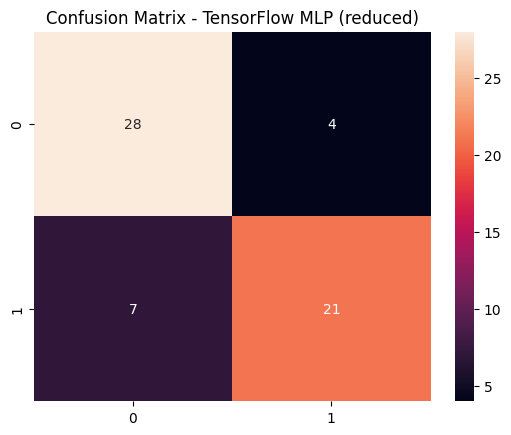

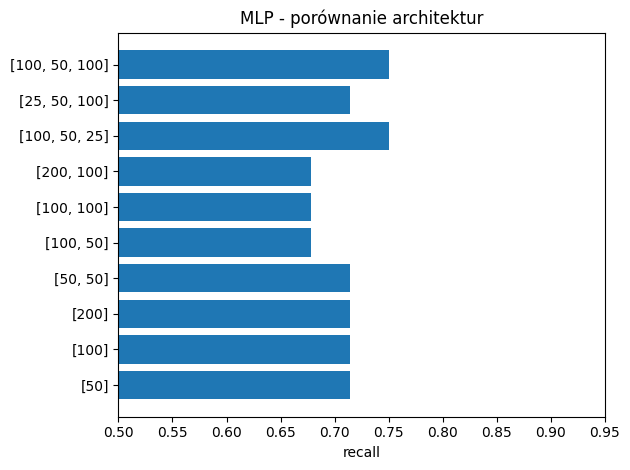

In [27]:
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
architectures = [
    [50],
    [100],
    [200],
    [50,50],
    [100,50],
    [100,100],
    [200,100],
    [100,50,25],
    [25,50,100],
    [100,50,100]
]
arch_accs = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test, y_test, verbose=0, return_dict=True)[SCORING]
  arch_accs.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

model = train_model(best['layers'], 'relu', 'adam', 0.2, 200)
y_pred_TF_proba = model.predict(X_test, verbose=0)
y_pred_TF = (y_pred_TF_proba > 0.4).astype(int)
results_a['MLP TensorFlow (reduced)'], results_r['MLP TensorFlow (reduced)'], results_p['MLP TensorFlow (reduced)'] = model_summary(y_test, y_pred_TF, "MLP TensorFlow (reduced)")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_accs)
plt.xlabel(SCORING)
plt.title('MLP - porównanie architektur')
plt.xlim(0.5, 0.95)
plt.tight_layout()
plt.show()

## SVC

### Baseline

Accuracy:  0.8333
Recall:    0.7857
Precision: 0.8462

               precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



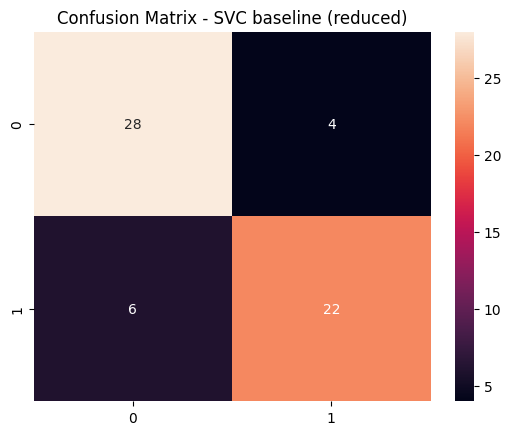

In [28]:
svc_baseline = SVC(random_state=RANDOM_STATE)
svc_baseline.fit(X_train, y_train)

y_pred_SVC_baseline = svc_baseline.predict(X_test)
results_a['SVC baseline (reduced)'], results_r['SVC baseline (reduced)'], results_p['SVC baseline (reduced)'] = model_summary(y_test, y_pred_SVC_baseline, "SVC baseline (reduced)")

In [29]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

svc_grid = SVC(random_state=RANDOM_STATE)
svc_grid = GridSearchCV(svc_grid, param_grid_svc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
svc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {svc_grid.best_params_}')
print(f'Recall (walidacja): {svc_grid.best_score_:.4f}')
print(f'Recall (test): {svc_grid.score(X_test, y_test):.4f}')

y_pred_SVC = svc_grid.predict(X_test)
results_a['SVC GridSearchCV (reduced)'], results_r['SVC GridSearchCV (reduced)'], results_p['SVC GridSearchCV (reduced)'] = model_summary(y_test, y_pred_SVC, "SVC GridSearchCV (reduced)")

KeyboardInterrupt: 

### Kernel comparison

In [30]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train, y_train)
    print(f'{kernel:10s} {svc.score(X_test, y_test):.4f}')

linear     0.7667
rbf        0.8333
poly       0.8500
sigmoid    0.7667


## KNeighborsClassifier

### Baseline

Accuracy:  0.8333
Recall:    0.7857
Precision: 0.8462

               precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



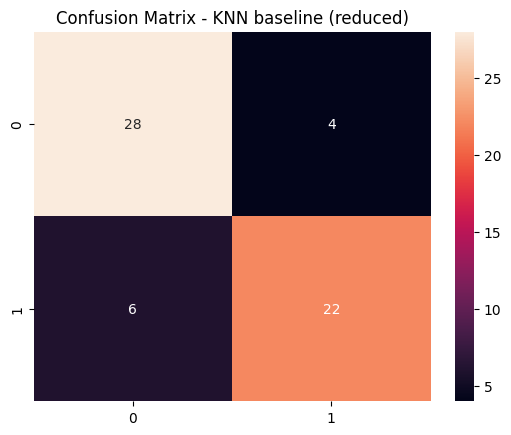

In [31]:
knn_base=KNC()
knn_base.fit(X_train,y_train)

y_pred_knn_base = knn_base.predict(X_test)
results_a['KNN baseline (reduced)'], results_r['KNN baseline (reduced)'], results_p['KNN baseline (reduced)'] = model_summary(y_test, y_pred_knn_base, "KNN baseline (reduced)")

### GridSearchCV

Najlepsze parametry: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Recall (walidacja): 0.7697
Recall (test): 0.7857
Accuracy:  0.8167
Recall:    0.7857
Precision: 0.8148

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        32
         1.0       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



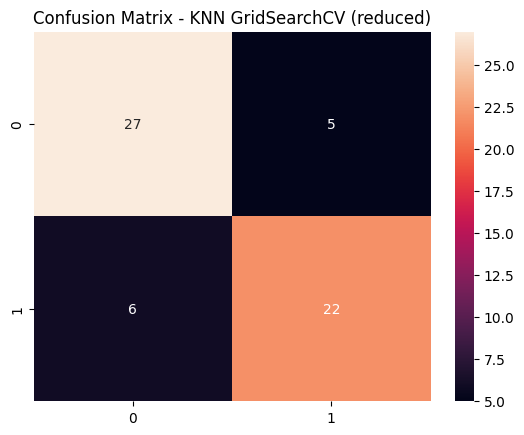

In [32]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = KNC()
knn_grid = GridSearchCV(knn_grid, param_grid_knn, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {knn_grid.best_params_}')
print(f'Recall (walidacja): {knn_grid.best_score_:.4f}')
print(f'Recall (test): {knn_grid.score(X_test, y_test):.4f}')

y_pred_knn = knn_grid.predict(X_test)
results_a['KNN GridSearchCV (reduced)'], results_r['KNN GridSearchCV (reduced)'], results_p['KNN GridSearchCV (reduced)'] = model_summary(y_test, y_pred_knn, "KNN GridSearchCV (reduced)")

## RandomForestClassifier

### Baseline

Accuracy:  0.7833
Recall:    0.7857
Precision: 0.7586

               precision    recall  f1-score   support

         0.0       0.81      0.78      0.79        32
         1.0       0.76      0.79      0.77        28

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



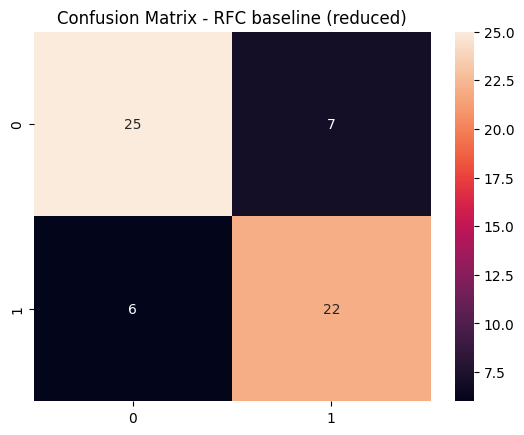

In [33]:
rfc_base = RFC(random_state=RANDOM_STATE)
rfc_base.fit(X_train, y_train)

y_pred_rfc_base = rfc_base.predict(X_test)
results_a['RFC baseline (reduced)'], results_r['RFC baseline (reduced)'], results_p['RFC baseline (reduced)'] = model_summary(y_test, y_pred_rfc_base, "RFC baseline (reduced)")

### GridSearchCV

Najlepsze parametry: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Recall (walidacja): 0.7420
Recall (test): 0.7857
Accuracy:  0.8167
Recall:    0.7857
Precision: 0.8148

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        32
         1.0       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



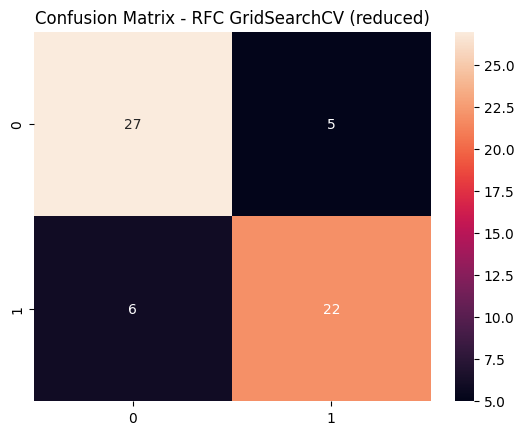

In [34]:
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = RFC(random_state=RANDOM_STATE)
rfc_grid = GridSearchCV(rfc_grid, param_grid_rfc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {rfc_grid.best_params_}')
print(f'Recall (walidacja): {rfc_grid.best_score_:.4f}')
print(f'Recall (test): {rfc_grid.score(X_test, y_test):.4f}')

y_pred_rfc = rfc_grid.predict(X_test)
results_a['RFC GridSearchCV (reduced)'], results_r['RFC GridSearchCV (reduced)'], results_p['RFC GridSearchCV (reduced)'] = model_summary(y_test, y_pred_rfc, "RFC GridSearchCV (reduced)")

### Feature importance

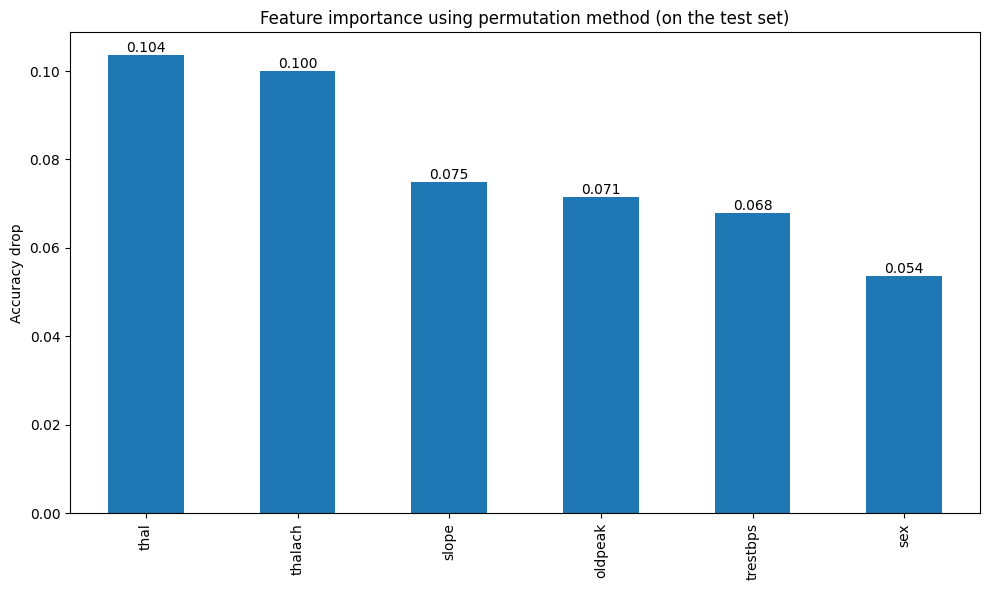

In [35]:
result = permutation_importance(
    rfc_grid, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = perm_importances.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.3f')
plt.title("Feature importance using permutation method (on the test set)")
plt.ylabel("Accuracy drop")
plt.tight_layout()
plt.show()

# Overall model comparison

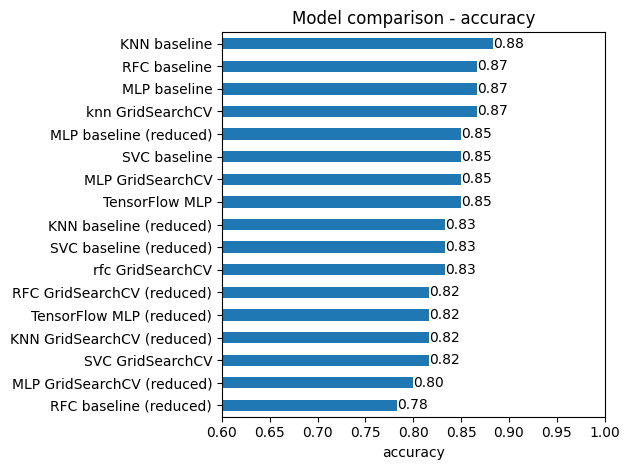

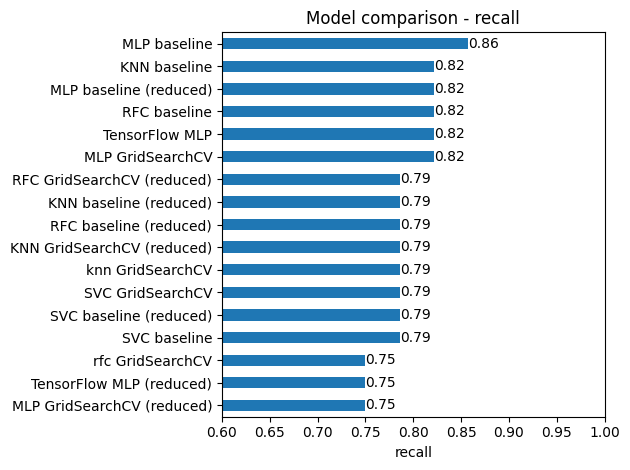

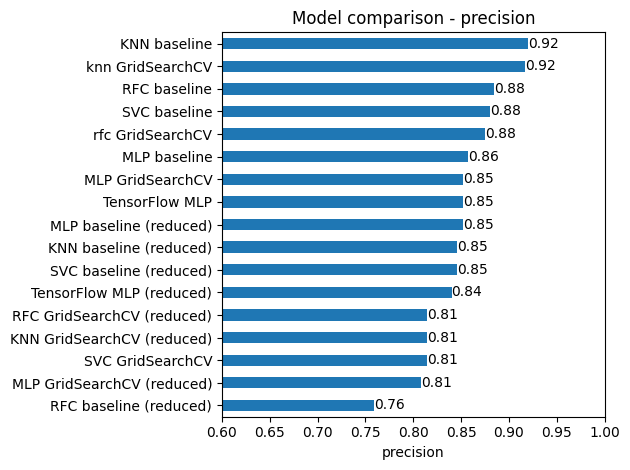

In [36]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  ax = pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  ax.bar_label(ax.containers[0], fmt='%.2f')
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()